In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn
seaborn.set_style("darkgrid")
pd.plotting.register_matplotlib_converters()

#import seaborn as sns
import math as m
import statsmodels
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict
import csv

## Data

This data is taken from an MQL4 terminal using FusionMarkets personal account. The data was retrieve as of 18 of July 2023. Assuming the data is downloaded in the format that the MQL4 provides then, the data should be in the following order:

* Time, Open, High, Low, Close, Volume

In [5]:
nms = ["Time", "Open", "High", "Low", "Close", "Volume"]

d = pd.read_csv(".\\GBPUSD1.csv", names = nms)
type(d)

pandas.core.frame.DataFrame

In [6]:
df = pd.DataFrame(data = d)

df.head()

,Time,Open,High,Low,Close,Volume
2023.05.16,00:40,1.25260,1.25269,1.25260,1.25269,4
2023.05.16,00:41,1.25254,1.25276,1.25254,1.25276,2
2023.05.16,00:42,1.25278,1.25278,1.25265,1.25265,2
2023.05.16,00:43,1.25265,1.25279,1.25265,1.25265,3
2023.05.16,00:44,1.25262,1.25279,1.25257,1.25279,5


In [7]:
len(df)

65013

## Recipe 2
Step 1. Extracting values from csv file using python included library csv.<br>
Step 2. Define a function to extract values.<br>
Step 3. Save each row in a different variable.<br>
Step 4. Build a dataframe with the defined variables.<br>

In [2]:
GBPUSD1 = []

with open('GBPUSD1.csv', newline='') as f:
    datareader = csv.reader(f, delimiter=',')
    for row in datareader:
        print(row)
        GBPUSD1.append(row)

['2023.05.16', '00:40', '1.25260', '1.25269', '1.25260', '1.25269', '4']
['2023.05.16', '00:41', '1.25254', '1.25276', '1.25254', '1.25276', '2']
['2023.05.16', '00:42', '1.25278', '1.25278', '1.25265', '1.25265', '2']
['2023.05.16', '00:43', '1.25265', '1.25279', '1.25265', '1.25265', '3']
['2023.05.16', '00:44', '1.25262', '1.25279', '1.25257', '1.25279', '5']
['2023.05.16', '00:45', '1.25279', '1.25279', '1.25279', '1.25279', '1']
['2023.05.16', '00:46', '1.25279', '1.25279', '1.25267', '1.25267', '2']
['2023.05.16', '00:47', '1.25279', '1.25281', '1.25266', '1.25281', '4']
['2023.05.16', '00:48', '1.25266', '1.25288', '1.25263', '1.25274', '8']
['2023.05.16', '00:49', '1.25263', '1.25274', '1.25263', '1.25274', '4']
['2023.05.16', '00:50', '1.25279', '1.25282', '1.25274', '1.25282', '7']
['2023.05.16', '00:51', '1.25265', '1.25281', '1.25263', '1.25281', '4']
['2023.05.16', '00:52', '1.25282', '1.25282', '1.25266', '1.25266', '2']
['2023.05.16', '00:53', '1.25266', '1.25266', '1.25

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [3]:
len(GBPUSD1)

65013

In [4]:
#Step 2:  Define a function to extract values.

def retriever(val: list, x: list, ind: int): 
    '''FUNCTION TO EXTRACT VALUES
    val is the output variable
    x is the container of data "to extract values from"
    ind is the row of the container 
    '''
    for i in range(0, len(x)):
        val.append(x[i][ind])

In [5]:
# Step 3. Save each row in a different variable.
valDates = []
valTime = []
valsOpen = []
valsHigh = []
valsLow = []
valsClose = []
valsVol = []
retriever(valDates, GBPUSD1, 0)
retriever(valTime, GBPUSD1, 1)
retriever(valsOpen, GBPUSD1, 2)
retriever(valsHigh, GBPUSD1, 3)
retriever(valsLow, GBPUSD1, 4)
retriever(valsClose, GBPUSD1, 5)
retriever(valsVol, GBPUSD1, 6)

In [6]:
len(valsOpen)

65013

In [7]:
print(valDates[0:10])
print(valTime[0:10])

print(valsOpen[0:10])
print(valsHigh[0:10])
print(valsLow[0:10])
print(valsClose[0:10])

print(valsVol[0:10])

['2023.05.16', '2023.05.16', '2023.05.16', '2023.05.16', '2023.05.16', '2023.05.16', '2023.05.16', '2023.05.16', '2023.05.16', '2023.05.16']
['00:40', '00:41', '00:42', '00:43', '00:44', '00:45', '00:46', '00:47', '00:48', '00:49']
['1.25260', '1.25254', '1.25278', '1.25265', '1.25262', '1.25279', '1.25279', '1.25279', '1.25266', '1.25263']
['1.25269', '1.25276', '1.25278', '1.25279', '1.25279', '1.25279', '1.25279', '1.25281', '1.25288', '1.25274']
['1.25260', '1.25254', '1.25265', '1.25265', '1.25257', '1.25279', '1.25267', '1.25266', '1.25263', '1.25263']
['1.25269', '1.25276', '1.25265', '1.25265', '1.25279', '1.25279', '1.25267', '1.25281', '1.25274', '1.25274']
['4', '2', '2', '3', '5', '1', '2', '4', '8', '4']


In [15]:
print(valsOpen[0:10])
print(valsOpen[64988:65012])

['1.25260', '1.25254', '1.25278', '1.25265', '1.25262', '1.25279', '1.25279', '1.25279', '1.25266', '1.25263']
['1.30953', '1.30946', '1.30952', '1.31007', '1.30993', '1.30980', '1.30968', '1.30976', '1.30966', '1.30966', '1.30966', '1.30938', '1.30920', '1.30918', '1.30899', '1.30897', '1.30894', '1.30891', '1.30874', '1.30874', '1.30868', '1.30875', '1.30873', '1.30871']


In [10]:
print(type(valsOpen[0:10]))
print(type(valsHigh[0:10]))
print(type(valsLow[0:10]))
print(type(valsClose[0:10]))
print(type(valsVol[0:10]))

<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>


In [34]:
valDates[0:10]

['2023.05.16',
 '2023.05.16',
 '2023.05.16',
 '2023.05.16',
 '2023.05.16',
 '2023.05.16',
 '2023.05.16',
 '2023.05.16',
 '2023.05.16',
 '2023.05.16']

In [37]:
np.array(valDates, dtype=np.npy_datetime)

AttributeError: module 'numpy' has no attribute 'npy_datetime'

In [35]:
np.datetime64(valDates[0])

ValueError: Error parsing datetime string "2023.05.16" at position 4

For the next step we need to homologize the dataset and by that we mean to convert the type of the variables into numerical types. Numpy has the perfect tool for that.

In [28]:
itValDates = map(np.datetime64(), valDates)
itValTime = map(np.datetime64(), valTime)

In [30]:
valDates = []
valTime = []

ValDates = itValDates
valTime = itValTime

TypeError: 'map' object is not subscriptable

In [8]:
#np.array(valDates, dtype=np.datetime64)
#np.array(valTime, dtype=np.datetime64)
vOpen = np.array(valsOpen, dtype=float)
vHgh = np.array(valsHigh, dtype=float)
vLw = np.array(valsLow, dtype=float)
vCl = np.array(valsClose, dtype=float)
vVol = np.array(valsVol, dtype=int)


In [9]:


def SMAv(val, ser): 
    for i in range(0, len(vOpen)):
        val.append(np.average(ser[0:i]))# 0-0; 0-1; 0-2; 0-3...

In [10]:
vOSMAv = []
SMAv(vOSMAv, vOpen)
vHSMAv = []
SMAv(vHSMAv, vHgh)

C:\Users\crisd\.pyvenvs\datatools310\datatools\lib\site-packages\numpy\lib\_function_base_impl.py:562: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
C:\Users\crisd\.pyvenvs\datatools310\datatools\lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [11]:
vOSMAv[0:10]

[np.float64(nan),
 np.float64(1.2526),
 np.float64(1.25257),
 np.float64(1.25264),
 np.float64(1.2526424999999999),
 np.float64(1.252638),
 np.float64(1.2526633333333332),
 np.float64(1.2526814285714285),
 np.float64(1.2526950000000001),
 np.float64(1.2526911111111112)]

In [16]:
len(vOSMAv)

65013

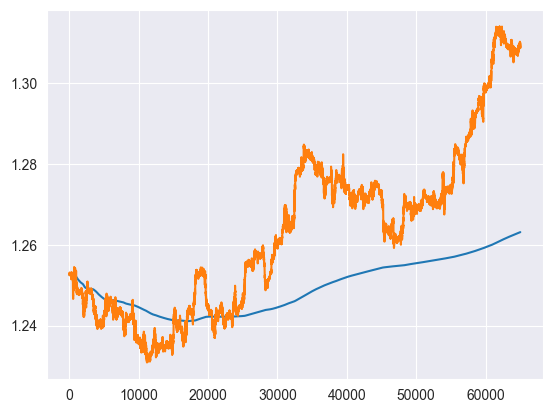

In [13]:
fig, ax = plt.subplots()
ax.plot(vOSMAv)
ax.plot(vOpen)

## Let's fit an ARIMA Model to forecast the values of the open in the market

- Fit an ARIMA model to your observed priceGas.
- Extract the estimated AR and MA coefficients.
- Convert them into the format required by arma_generate_sample.

In [6]:
priceGas = np.array(valsOpen, dtype=float)
# Normalize
priceGas_scaled = (priceGas - priceGas.mean()) / priceGas.std()

In [7]:
returns = np.diff(np.log(priceGas))
returns = 
model = ARIMA(returns, order=(1,0,1))  # (p,d,q)4model_fit = model.fit()
model_fit = model.fit()
params = model_fit.params
print(params)

C:\Users\crisd\.pyvenvs\datatools310\datatools\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[ 6.76623061e-07  2.31331342e-01 -2.62670585e-01  1.72114619e-08]


In [10]:
print(len(returns))

65012


In [11]:
print(returns[0:10])

[-4.79015145e-05  1.91592292e-04 -1.03774602e-04 -2.39495144e-05
  1.35706332e-04  0.00000000e+00  0.00000000e+00 -1.03773773e-04
 -2.39493232e-05  1.27723097e-04]


In [ ]:
print(

In [18]:
#arparams = np.array([model_fit.arparams]) if model_fit.k_ar > 0 else np.array([])
#maparams = np.array([model_fit.maparams]) if model_fit.k_ma > 0 else np.array([])

AttributeError: 'ARIMAResults' object has no attribute 'k_ar'

In [8]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                65012
Model:                 ARIMA(1, 0, 1)   Log Likelihood              488885.705
Date:                Wed, 01 Jul 2026   AIC                        -977763.410
Time:                        23:17:57   BIC                        -977727.081
Sample:                             0   HQIC                       -977752.167
                              - 65012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.766e-07   4.94e-07      1.370      0.171   -2.91e-07    1.64e-06
ar.L1          0.2313   7.89e-12   2.93e+10      0.000       0.231       0.231
ma.L1         -0.2627   7.81e-12  -3.36e+10      0.0

In [9]:
forecast = model_fit.get_forecast(100)

KeyError: 'The `start` argument could not be matched to a location related to the index of the data.'

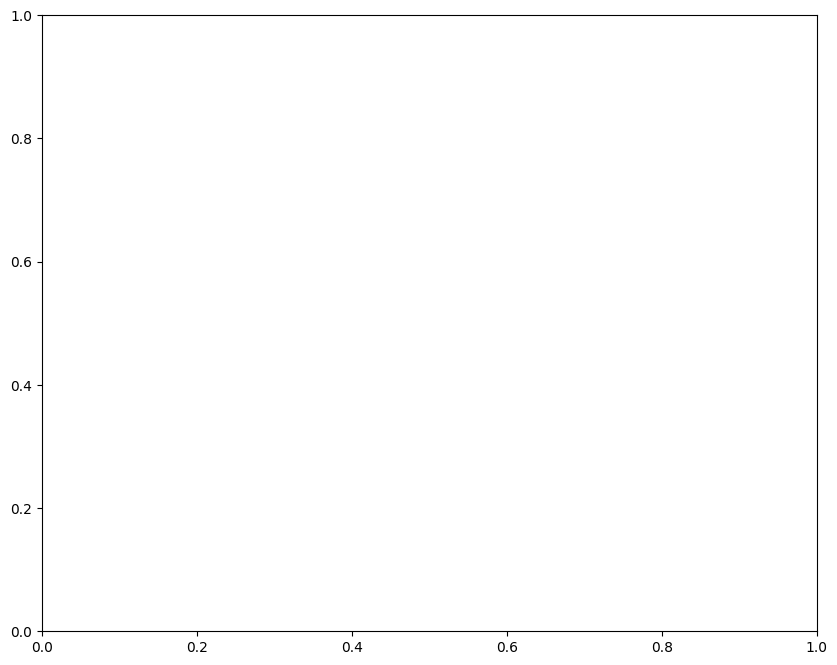

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
fig = plot_predict(model_fit, start=returns[0], end=returns[65011], ax=ax)
legend = ax.legend(loc="upper left")

In [ ]:
# Adding these arguments only after further analysis
#ar = np.r_[1, -arparams.flatten()]
#ma = np.r_[1, maparams.flatten()]

In [ ]:
nobs = len(priceGas)        SA  # same length (interpolation-like)